<a href="https://colab.research.google.com/github/naeem92khatri-afk/Assignment_3-Data-Visualization/blob/main/Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1, Data Uploading and Creation

In [1]:
import pandas as pd
import numpy as np
from random import choice, randint, uniform

# Set a seed for reproducibility
np.random.seed(42)

# Define the number of records
N = 250

# Create synthetic data columns
data = {
    'CustomerID': np.arange(1001, 1001 + N),
    'Age': np.random.randint(20, 71, N),
    'Gender': [choice(['Male', 'Female', 'Other', np.nan]) for _ in range(N)],
    'ProductCategory': [choice(['Electronics', 'Apparel', 'Home Goods', 'Books']) for _ in range(N)],
    'PurchaseAmount': np.round(np.random.uniform(10.0, 500.0, N), 2),
    'PaymentMethod': [choice(['Credit Card', 'Debit Card', 'PayPal', 'Cash']) for _ in range(N)],
    'ReviewScore': np.round(np.random.uniform(1.0, 5.0, N), 1),
    'IsFirstPurchase': np.random.choice([True, False], N, p=[0.2, 0.8]),
    'DaysSinceLastPurchase': np.random.randint(1, 366, N)
}

# Create the DataFrame
df = pd.DataFrame(data)

# Introduce some missing values (for cleaning step)
df.loc[df.sample(frac=0.05).index, 'Age'] = np.nan  # 5% missing Age
df.loc[df.sample(frac=0.03).index, 'PurchaseAmount'] = np.nan # 3% missing PurchaseAmount
df.loc[df.sample(frac=0.05).index, 'Gender'] = np.nan # Additional 5% missing Gender

print(f"Dataset created with {len(df)} records.")
print(df.head())

Dataset created with 250 records.
   CustomerID   Age  Gender ProductCategory  PurchaseAmount PaymentMethod  \
0        1001  58.0  Female         Apparel           83.85   Credit Card   
1        1002  48.0  Female     Electronics          259.02          Cash   
2        1003  34.0     NaN     Electronics          350.95   Credit Card   
3        1004  62.0    Male           Books          430.60          Cash   
4        1005  27.0    Male     Electronics          169.72    Debit Card   

   ReviewScore  IsFirstPurchase  DaysSinceLastPurchase  
0          1.4            False                     53  
1          3.4            False                    355  
2          3.2            False                    342  
3          1.9             True                    364  
4          4.8            False                    280  


2, Data Cleaning

In [2]:
# Check for missing values
print("--- Missing Values before Cleaning ---")
print(df.isnull().sum())

# 1. Handle Missing Values:
# a) Fill missing 'Gender' with the mode (most frequent value)
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)

# b) Fill missing 'Age' with the median
df['Age'].fillna(df['Age'].median(), inplace=True)

# c) Drop rows where 'PurchaseAmount' is missing (since it's a key metric)
df.dropna(subset=['PurchaseAmount'], inplace=True)

# 2. Check and Convert Data Types:
# Ensure Age is an integer
df['Age'] = df['Age'].astype(int)

# 3. Handle Inconsistent Data (if any):
# Example: Convert 'ProductCategory' to title case if needed
df['ProductCategory'] = df['ProductCategory'].str.title()

# Final check
print("\n--- Missing Values after Cleaning ---")
print(df.isnull().sum())
print("\n--- Data Types after Cleaning ---")
print(df.dtypes)

--- Missing Values before Cleaning ---
CustomerID                0
Age                      12
Gender                   72
ProductCategory           0
PurchaseAmount            8
PaymentMethod             0
ReviewScore               0
IsFirstPurchase           0
DaysSinceLastPurchase     0
dtype: int64

--- Missing Values after Cleaning ---
CustomerID               0
Age                      0
Gender                   0
ProductCategory          0
PurchaseAmount           0
PaymentMethod            0
ReviewScore              0
IsFirstPurchase          0
DaysSinceLastPurchase    0
dtype: int64

--- Data Types after Cleaning ---
CustomerID                 int64
Age                        int64
Gender                    object
ProductCategory           object
PurchaseAmount           float64
PaymentMethod             object
ReviewScore              float64
IsFirstPurchase             bool
DaysSinceLastPurchase      int64
dtype: object


/tmp/ipython-input-2860370815.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
/tmp/ipython-input-2860370815.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

3, Data Manipulation

In [3]:
# 1. Create a **Customer Age Group** column (Binning)
bins = [18, 30, 45, 60, 100]
labels = ['Young Adult', 'Middle Aged', 'Senior', 'Elderly']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# 2. Create a **HighValue** flag (Boolean feature)
# Define a High Value customer as one with a purchase > $250
df['IsHighValue'] = df['PurchaseAmount'] > 250

# 3. Create a **Recency Category**
# Classify based on DaysSinceLastPurchase
# The corrected implementation from your previous step
df['RecencyCategory'] = np.select(
    [df['DaysSinceLastPurchase'] <= 30,
     df['DaysSinceLastPurchase'] <= 90,
     df['DaysSinceLastPurchase'] > 90],
    ['Recent (<= 30d)', 'Active (31-90d)', 'Lapsed (> 90d)'], # Choicelist (all strings)
    # The crucial fix: If a default value is needed, it must also be a string
    default='Other' # Ensure the default value is a STRING
)

print("\n--- Manipulated Data Head ---")
print(df[['Age', 'AgeGroup', 'PurchaseAmount', 'IsHighValue', 'RecencyCategory']].head())


--- Manipulated Data Head ---
   Age     AgeGroup  PurchaseAmount  IsHighValue  RecencyCategory
0   58       Senior           83.85        False  Active (31-90d)
1   48       Senior          259.02         True   Lapsed (> 90d)
2   34  Middle Aged          350.95         True   Lapsed (> 90d)
3   62      Elderly          430.60         True   Lapsed (> 90d)
4   27  Young Adult          169.72        False   Lapsed (> 90d)


4, Data Visualization

/tmp/ipython-input-3410303572.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='ProductCategory', data=df, order=df['ProductCategory'].value_counts().index, ax=axes[1], palette='viridis')


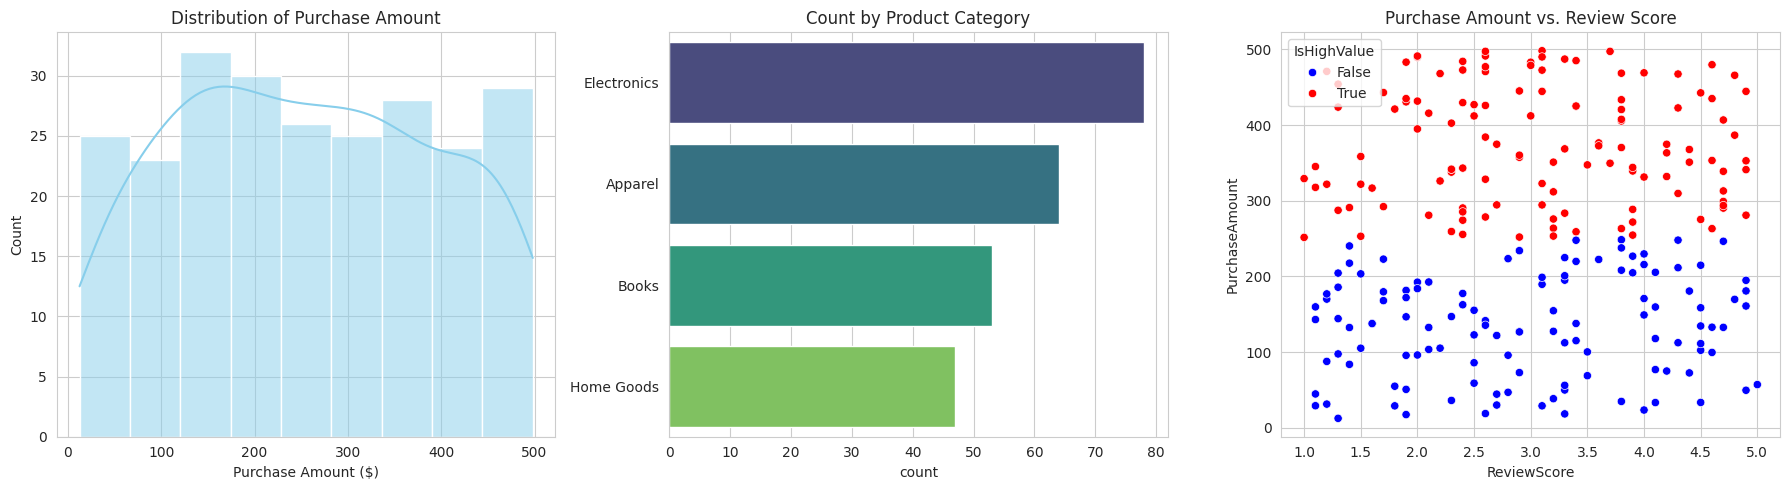

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Create a figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribution of Purchase Amount (Quantitative)
sns.histplot(df['PurchaseAmount'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Purchase Amount')
axes[0].set_xlabel('Purchase Amount ($)')

# 2. Category Breakdown (Categorical Count)
sns.countplot(y='ProductCategory', data=df, order=df['ProductCategory'].value_counts().index, ax=axes[1], palette='viridis')
axes[1].set_title('Count by Product Category')
axes[1].set_ylabel('')

# 3. Relationship between Purchase Amount and Review Score (Scatter Plot)
sns.scatterplot(x='ReviewScore', y='PurchaseAmount', data=df, hue='IsHighValue', palette={True: 'red', False: 'blue'}, ax=axes[2])
axes[2].set_title('Purchase Amount vs. Review Score')

plt.tight_layout()
plt.show()

5, Feature Engineering

In [5]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Identify categorical and numerical columns for feature engineering
categorical_features = ['Gender', 'ProductCategory', 'PaymentMethod']
numerical_features = ['Age', 'PurchaseAmount', 'DaysSinceLastPurchase', 'ReviewScore']

# 1. One-Hot Encoding for Categorical Variables
# 2. Standardization (Scaling) for Numerical Variables

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ],
    remainder='passthrough' # Keep other columns like CustomerID, AgeGroup, etc.
)

# Apply the transformations
features_processed = preprocessor.fit_transform(df)

# Create a DataFrame from the processed features for inspection
# Get the new feature names
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
num_feature_names = numerical_features
new_feature_names = np.concatenate([cat_feature_names, num_feature_names])

df_processed = pd.DataFrame(features_processed[:, :len(new_feature_names)], columns=new_feature_names)

print("\n--- Engineered Features Head (Ready for Modeling) ---")
print(df_processed.head())
print(f"\nOriginal features: {df.shape[1]}")
print(f"Engineered features: {df_processed.shape[1]} (after encoding and scaling)")


--- Engineered Features Head (Ready for Modeling) ---
  Gender_Female Gender_Male Gender_Other ProductCategory_Apparel  \
0           1.0         0.0          0.0                     1.0   
1           1.0         0.0          0.0                     0.0   
2           0.0         0.0          1.0                     0.0   
3           0.0         1.0          0.0                     0.0   
4           0.0         1.0          0.0                     0.0   

  ProductCategory_Books ProductCategory_Electronics  \
0                   0.0                         0.0   
1                   0.0                         1.0   
2                   0.0                         1.0   
3                   1.0                         0.0   
4                   0.0                         1.0   

  ProductCategory_Home Goods PaymentMethod_Cash PaymentMethod_Credit Card  \
0                        0.0                0.0                       1.0   
1                        0.0                1.0    

6, Lable Encoding

In [6]:
from sklearn.preprocessing import LabelEncoder

# Create a copy to avoid SettingWithCopyWarning
df_encoded = df.copy()

# Initialize the LabelEncoder
le = LabelEncoder()

# Fit and transform the 'Gender' column
df_encoded['Gender_LabelEncoded'] = le.fit_transform(df_encoded['Gender'])

print("--- Label Encoded 'Gender' ---")
print(df_encoded[['Gender', 'Gender_LabelEncoded']].head())
print(f"\nUnique Mappings: {dict(zip(le.classes_, le.transform(le.classes_)))}")

--- Label Encoded 'Gender' ---
   Gender  Gender_LabelEncoded
0  Female                    0
1  Female                    0
2   Other                    2
3    Male                    1
4    Male                    1

Unique Mappings: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}


7, One hot Encoding

In [7]:
from sklearn.preprocessing import OneHotEncoder

# Select the column to encode
ohe_data = df_encoded[['ProductCategory']]

# Initialize the OneHotEncoder
# 'sparse_output=False' ensures the output is a NumPy array, not a sparse matrix
ohe = OneHotEncoder(sparse_output=False)

# Fit and transform
ohe_features = ohe.fit_transform(ohe_data)

# Create a DataFrame with the new feature names
ohe_df = pd.DataFrame(ohe_features, columns=ohe.get_feature_names_out(['ProductCategory']), index=df_encoded.index)

# Join the new columns back to the main DataFrame
df_encoded = pd.concat([df_encoded, ohe_df], axis=1)

print("\n--- One-Hot Encoded 'ProductCategory' ---")
print(df_encoded[['ProductCategory'] + list(ohe_df.columns)].head())


--- One-Hot Encoded 'ProductCategory' ---
  ProductCategory  ProductCategory_Apparel  ProductCategory_Books  \
0         Apparel                      1.0                    0.0   
1     Electronics                      0.0                    0.0   
2     Electronics                      0.0                    0.0   
3           Books                      0.0                    1.0   
4     Electronics                      0.0                    0.0   

   ProductCategory_Electronics  ProductCategory_Home Goods  
0                          0.0                         0.0  
1                          1.0                         0.0  
2                          1.0                         0.0  
3                          0.0                         0.0  
4                          1.0                         0.0  


8, Standardization

In [8]:
from sklearn.preprocessing import StandardScaler

# Select the feature to scale (requires reshaping to 2D array)
amount_data = df[['PurchaseAmount']]

# Initialize the StandardScaler
scaler_standard = StandardScaler()

# Fit and transform
df['PurchaseAmount_StandardScaled'] = scaler_standard.fit_transform(amount_data)

print("\n--- Standard Scaling (Standard Deviation) ---")
print(df[['PurchaseAmount', 'PurchaseAmount_StandardScaled']].head())
print(f"Mean: {scaler_standard.mean_[0]:.4f}, Std Dev: {np.sqrt(scaler_standard.var_[0]):.4f}")


--- Standard Scaling (Standard Deviation) ---
   PurchaseAmount  PurchaseAmount_StandardScaled
0           83.85                      -1.235838
1          259.02                       0.015952
2          350.95                       0.672896
3          430.60                       1.242087
4          169.72                      -0.622199
Mean: 256.7878, Std Dev: 139.9356


9, Polynomial Features

In [9]:
from sklearn.preprocessing import PolynomialFeatures

# Select the features for polynomial transformation
poly_features_data = df[['Age', 'ReviewScore']]

# Initialize PolynomialFeatures:
# degree=2 means x, x^2, y, y^2, and the interaction term x*y
# include_bias=False prevents adding a column of all 1s
poly = PolynomialFeatures(degree=2, include_bias=False)

# Fit and transform
poly_features = poly.fit_transform(poly_features_data)

# Create a DataFrame with the new features
poly_df = pd.DataFrame(
    poly_features,
    columns=poly.get_feature_names_out(['Age', 'ReviewScore']),
    index=df.index
)

print("\n--- Polynomial Features (Degree 2) ---")
print(poly_df.head())


--- Polynomial Features (Degree 2) ---
    Age  ReviewScore   Age^2  Age ReviewScore  ReviewScore^2
0  58.0          1.4  3364.0             81.2           1.96
1  48.0          3.4  2304.0            163.2          11.56
2  34.0          3.2  1156.0            108.8          10.24
3  62.0          1.9  3844.0            117.8           3.61
4  27.0          4.8   729.0            129.6          23.04
